
# Common statistical tests as linear models: Using a small clinical example

After reading Jonas Kristoffer Lindelov's *Common statistical tests are linear models*, I used LLMs to help understand the topic and come up with an example to support the article. This notebook uses a simple clinical-style dataset to show how the following tests relate to each other:

- Student's two-sample t-test
- Mann-Whitney U test
- Wilcoxon signed-rank test
- Wald test

The main idea from Lindelov is that many statistical tests can be written as versions of a model like:

$$
\text{outcome} = \text{intercept} + \text{effect of group/treatment} + \text{error}
$$

The tests differ mostly in what outcome is modeled and what assumptions are made.



## Clinical example

Imagine a small randomized clinical trial of a pain medication.

Patients are randomized into:

- Control
- Treatment

Each patient has a pain score measured at baseline and after 4 weeks. Pain is measured on a 0 to 10 scale, where lower is better.

To compare that tests in a clinical context the following endpoints are created:

1. A continuous endpoint: **pain improvement = baseline pain - week 4 pain**
2. A paired endpoint: **within-patient change from baseline to week 4**
3. A binary endpoint: **responder = at least 2-point improvement**



In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(42)

# Simulate a small clinical trial
n_per_group = 30

control_baseline = np.random.normal(loc=6.5, scale=1.0, size=n_per_group)
treatment_baseline = np.random.normal(loc=6.5, scale=1.0, size=n_per_group)

# Control improves a little, treatment improves more
control_improvement = np.random.normal(loc=1.0, scale=1.1, size=n_per_group)
treatment_improvement = np.random.normal(loc=2.0, scale=1.1, size=n_per_group)

control_week4 = control_baseline - control_improvement
treatment_week4 = treatment_baseline - treatment_improvement

df = pd.DataFrame({
    "patient_id": range(1, 2*n_per_group + 1),
    "group": ["Control"] * n_per_group + ["Treatment"] * n_per_group,
    "baseline_pain": np.concatenate([control_baseline, treatment_baseline]),
    "week4_pain": np.concatenate([control_week4, treatment_week4]),
    "improvement": np.concatenate([control_improvement, treatment_improvement])
})

# Keep pain scores in a realistic range
df["baseline_pain"] = df["baseline_pain"].clip(0, 10)
df["week4_pain"] = df["week4_pain"].clip(0, 10)
df["improvement"] = df["baseline_pain"] - df["week4_pain"]

# Binary responder outcome
df["responder"] = (df["improvement"] >= 2).astype(int)

df.head()


,patient_id,group,baseline_pain,week4_pain,improvement,responder
0,1,Control,6.996714,6.523806,0.472908,0
1,2,Control,6.361736,5.565961,0.795775,0
2,3,Control,7.147689,7.364657,-0.216968,0
3,4,Control,8.023030,8.338857,-0.315827,0
4,5,Control,6.265847,4.372068,1.893778,0



## Quick look at the data


In [3]:

df.groupby("group")[["baseline_pain", "week4_pain", "improvement", "responder"]].agg(["mean", "std"])


baseline_pain           week4_pain           improvement            \
                   mean       std       mean       std        mean       std   
group                                                                          
Control        6.311853  0.900006   5.297680  1.421906    1.014173  1.091181   
Treatment      6.378838  0.931102   4.401114  1.248157    1.977723  0.999704   

          responder            
               mean       std  
group                          
Control    0.200000  0.406838  
Treatment  0.466667  0.507416

C:\Users\balle\AppData\Local\Temp\ipykernel_3500\2174714700.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


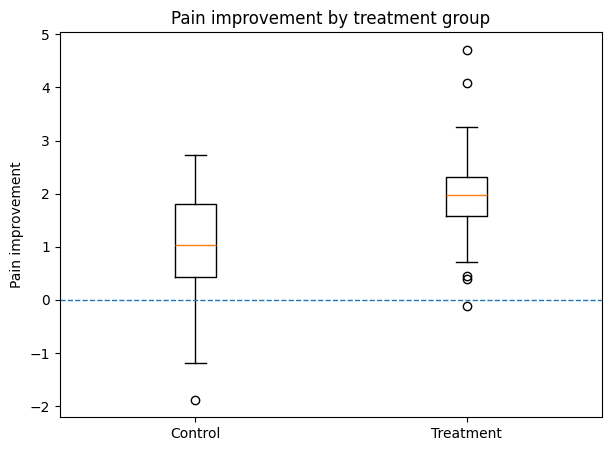

In [4]:

plt.figure(figsize=(7, 5))
groups = ["Control", "Treatment"]
data = [df.loc[df["group"] == g, "improvement"] for g in groups]

plt.boxplot(data, labels=groups)
plt.ylabel("Pain improvement")
plt.title("Pain improvement by treatment group")
plt.axhline(0, linestyle="--", linewidth=1)
plt.show()



# 1. Student's two-sample t-test

The two-sample t-test asks whether the **mean improvement** differs between the treatment and control groups.

In linear model language, this is the same idea as:

$$
\text{improvement}_i = \beta_0 + \beta_1 \cdot \text{Treatment}_i + \epsilon_i
$$

Where:

- $\beta_0$ = mean improvement in the control group
- $\beta_1$ = extra mean improvement in the treatment group
- The t-test checks whether $\beta_1 = 0$

So the t-test is basically a test of the treatment coefficient in a linear model.


In [5]:

control = df.loc[df["group"] == "Control", "improvement"]
treatment = df.loc[df["group"] == "Treatment", "improvement"]

ttest_result = stats.ttest_ind(treatment, control, equal_var=True)

print("Student's two-sample t-test")
print(f"t statistic = {ttest_result.statistic:.3f}")
print(f"p-value     = {ttest_result.pvalue:.4f}")


Student's two-sample t-test
t statistic = 3.566
p-value     = 0.0007


In [7]:

# Same idea as a linear model
lm_ttest = smf.ols("improvement ~ group", data=df).fit()

pd.DataFrame({
    "value": [
        lm_ttest.params["group[T.Treatment]"],
        lm_ttest.tvalues["group[T.Treatment]"],
        lm_ttest.pvalues["group[T.Treatment]"]
    ]
}, index=[
    "Treatment effect coefficient",
    "t statistic",
    "p-value"
])


,value
Treatment effect coefficient,0.963550
t statistic,3.566189
p-value,0.000734



The coefficient for `group[T.Treatment]` is the estimated difference in mean improvement between treatment and control.

The t-statistic (3.566) for this coefficient is the same test idea as the Student's t-test, supporting Lindelov's point that a t-test can be written as a linear model.



# 2. Mann-Whitney U test

The Mann-Whitney U test compares two independent groups too, but instead of comparing raw values directly, it works with **ranks**.

A simple way to connect it to a linear model is:

$$
\text{rank(improvement)}_i = \beta_0 + \beta_1 \cdot \text{Treatment}_i + \epsilon_i
$$

This means the Mann-Whitney test is like comparing the groups after replacing the original clinical values with their ranks.

This is useful when the outcome is skewed, has outliers, or when we want a less assumption-heavy comparison.


In [8]:

mw_result = stats.mannwhitneyu(treatment, control, alternative="two-sided")

print("Mann-Whitney U test")
print(f"U statistic = {mw_result.statistic:.3f}")
print(f"p-value     = {mw_result.pvalue:.4f}")


Mann-Whitney U test
U statistic = 669.000
p-value     = 0.0012


In [12]:
# Rank-transformed outcome
df["rank_improvement"] = stats.rankdata(df["improvement"])

lm_rank = smf.ols("rank_improvement ~ group", data=df).fit()

rank_results = pd.DataFrame({
    "Value": [
        lm_rank.params["group[T.Treatment]"],
        lm_rank.tvalues["group[T.Treatment]"],
        lm_rank.pvalues["group[T.Treatment]"]
    ]
}, index=[
    "Treatment rank effect",
    "t statistic",
    "p-value"
])

rank_results

,Value
Treatment rank effect,14.600000
t statistic,3.540111
p-value,0.000796


C:\Users\balle\AppData\Local\Temp\ipykernel_3500\2094095954.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_ranked, labels=groups)


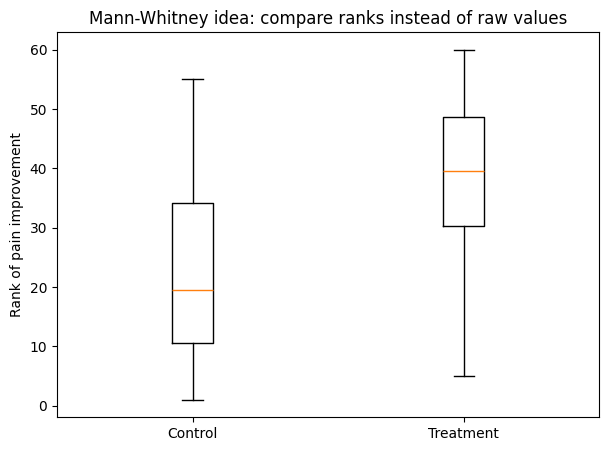

In [13]:

plt.figure(figsize=(7, 5))
data_ranked = [df.loc[df["group"] == g, "rank_improvement"] for g in groups]

plt.boxplot(data_ranked, labels=groups)
plt.ylabel("Rank of pain improvement")
plt.title("Mann-Whitney idea: compare ranks instead of raw values")
plt.show()



The Mann-Whitney U test and the rank-based linear model are not printed with exactly the same statistic, but they are testing the same general idea:

- Are treatment patients generally ranked higher in improvement than control patients?

So the t-test compares group means on the original scale, while Mann-Whitney compares groups on the rank scale.

In the example, the p-values are similar but not identical because the Mann–Whitney test and the linear model on ranks are related rather than exactly equivalent. Both methods analyze ranked outcomes, but they calculate their test statistics differently. However, I think the p-values (0.0012 v. 0.0008) are still reasonably close for a small simulated dataset.



# 3. Wilcoxon signed-rank test

The Wilcoxon signed-rank test is for paired data.

Here, each treatment patient has two measurements:

- Baseline pain
- Week 4 pain

The question here is:

- Did pain change within the same patients?

For this example, I use only the treatment group and test whether the median/typical change is different from zero.

In linear model language, the paired comparison can be written by first calculating the within-patient difference:

$$
d_i = \text{baseline pain}_i - \text{week 4 pain}_i
$$

Then the Wilcoxon signed-rank test works with the signed ranks of these differences.

A model version is:

$$
\text{signed rank}(d_i) = \beta_0 + \epsilon_i
$$

The test asks whether the intercept is different from zero.


In [14]:

treat_df = df[df["group"] == "Treatment"].copy()
differences = treat_df["baseline_pain"] - treat_df["week4_pain"]

wilcoxon_result = stats.wilcoxon(differences, alternative="two-sided")

print("Wilcoxon signed-rank test for treatment patients")
print(f"W statistic = {wilcoxon_result.statistic:.3f}")
print(f"p-value     = {wilcoxon_result.pvalue:.4f}")
print(f"Mean improvement = {differences.mean():.3f}")
print(f"Median improvement = {differences.median():.3f}")


Wilcoxon signed-rank test for treatment patients
W statistic = 1.000
p-value     = 0.0000
Mean improvement = 1.978
Median improvement = 1.966


In [15]:

# Create signed ranks manually
abs_rank = stats.rankdata(np.abs(differences))
signed_rank = np.sign(differences) * abs_rank

signed_rank_df = pd.DataFrame({
    "difference": differences,
    "signed_rank": signed_rank
})

signed_rank_df.head()


,difference,signed_rank
30,2.106785,19.0
31,3.065509,27.0
32,1.227742,6.0
33,1.639572,10.0
34,1.568681,8.0


In [16]:

# Linear model with only an intercept
lm_signed_rank = smf.ols("signed_rank ~ 1", data=signed_rank_df).fit()
lm_signed_rank.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            signed_rank   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 28 Apr 2026   Prob (F-statistic):                nan
Time:                        14:09:09   Log-Likelihood:                -107.72
No. Observations:                  30   AIC:                             217.4
Df Residuals:                      29   BIC:                             218.8
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.4333      1.629      9.473      0.000      12.101      18.766
==============================================================================
Omnibus:                        4.155   Durbin-Watson:                   1.486
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                1.611
Skew:                          -0.048   Prob(JB):                        0.447
Kurtosis:                       1.869   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

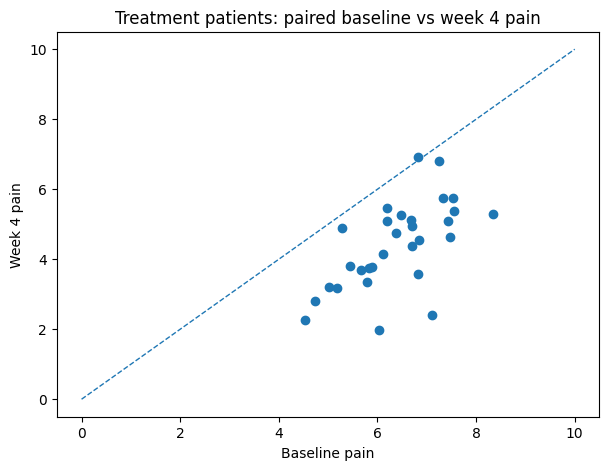

In [17]:

plt.figure(figsize=(7, 5))
plt.scatter(treat_df["baseline_pain"], treat_df["week4_pain"])
plt.plot([0, 10], [0, 10], linestyle="--", linewidth=1)
plt.xlabel("Baseline pain")
plt.ylabel("Week 4 pain")
plt.title("Treatment patients: paired baseline vs week 4 pain")
plt.show()



Points below the diagonal line improved because week 4 pain is lower than baseline pain.

The Wilcoxon signed-rank test is related to a one-sample/intercept-only model because after computing paired differences, there is only one thing to test: whether the typical difference is zero.



# 4. Wald test


$$
\text{Wald statistic} = \frac{\text{estimate}}{\text{standard error}}
$$

For a linear regression coefficient, this looks almost exactly like a t-statistic:

$$
t = \frac{\hat{\beta}_1 - 0}{SE(\hat{\beta}_1)}
$$

For large samples, Wald tests are often compared to a normal or chi-square distribution.

In clinical research, Wald tests often appear in regression models, such as logistic regression. Here we use the binary outcome:

$$
\text{responder} = 1 \quad \text{if pain improvement is at least 2 points}
$$

Then we fit:

$$
\text{logit}(P(\text{responder})) = \beta_0 + \beta_1 \cdot \text{Treatment}
$$

The Wald test checks whether the treatment coefficient $\beta_1$ is different from zero.


In [18]:

logit_model = smf.logit("responder ~ group", data=df).fit(disp=False)
logit_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              responder   No. Observations:                   60
Model:                          Logit   Df Residuals:                       58
Method:                           MLE   Df Model:                            1
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.06418
Time:                        14:13:09   Log-Likelihood:                -35.740
converged:                       True   LL-Null:                       -38.191
Covariance Type:            nonrobust   LLR p-value:                   0.02682
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.3863      0.456     -3.037      0.002      -2.281      -0.492
group[T.Treatment]     1.2528      0.585      2.141      0.032       0.106       2.399
======================================================================================
"""

In [19]:

coef = logit_model.params["group[T.Treatment]"]
se = logit_model.bse["group[T.Treatment]"]
wald_z = coef / se
wald_p = 2 * (1 - stats.norm.cdf(abs(wald_z)))

odds_ratio = np.exp(coef)

print("Wald test from logistic regression")
print(f"Treatment coefficient = {coef:.3f}")
print(f"Standard error        = {se:.3f}")
print(f"Wald z statistic      = {wald_z:.3f}")
print(f"p-value               = {wald_p:.4f}")
print(f"Odds ratio            = {odds_ratio:.3f}")


Wald test from logistic regression
Treatment coefficient = 1.253
Standard error        = 0.585
Wald z statistic      = 2.141
p-value               = 0.0322
Odds ratio            = 3.500


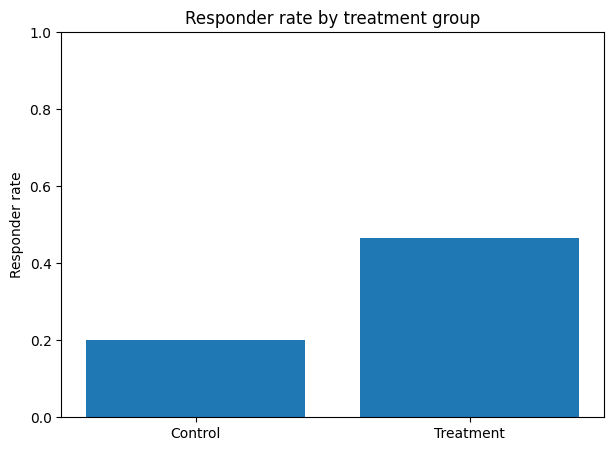

group
Control      0.200000
Treatment    0.466667
Name: responder, dtype: float64

In [20]:

responder_rates = df.groupby("group")["responder"].mean()

plt.figure(figsize=(7, 5))
plt.bar(responder_rates.index, responder_rates.values)
plt.ylabel("Responder rate")
plt.ylim(0, 1)
plt.title("Responder rate by treatment group")
plt.show()

responder_rates



# How the tests relate to each other

| Test | Data situation | What it compares | Linear-model connection |
|---|---|---|---|
| Student's t-test | Two independent groups, continuous outcome | Group means | Linear model on the raw outcome |
| Mann-Whitney U test | Two independent groups, ordinal/ranked or non-normal outcome | Group ranks | Linear model on ranked outcome |
| Wilcoxon signed-rank test | Paired data | Signed ranks of within-patient differences | Intercept-only model on signed ranks |
| Wald test | General regression setting | Estimate divided by standard error | Tests whether a model coefficient is zero |

From my understanding the main connection is that all four tests can be seen as asking whether a model coefficient or location parameter is different from zero.

The difference is mostly the scale of the outcome:

- t-test: raw clinical values
- Mann-Whitney: ranks of clinical values
- Wilcoxon signed-rank: signed ranks of paired differences
- Wald test: coefficient from a fitted model, such as logistic regression



# Interpretation

In this simulated clinical trial, the treatment group generally improved more than the control group. The Student's t-test checks whether the average improvement differs between groups. When we fit the same comparison as a linear model, the treatment coefficient gives the same type of answer.

The Mann-Whitney test looks similar, but it compares the ranking of improvements instead of the raw improvement scores. This makes it feel less dependent on the exact scale of the pain scores.

The Wilcoxon signed-rank test is different because it is paired. Instead of comparing two separate groups, it compares baseline and week 4 pain within the same patients. After calculating each patient's change, it asks whether the signed ranks of those changes are centered around zero.

The Wald test is the most general. It appears naturally in regression models. In the logistic regression example, it tests whether treatment changes the log-odds of being a responder. 

My main takeaway is that these tests are not totally separate tools. They are different versions of the same modeling idea: estimate an effect, calculate uncertainty around it, and test whether the effect is far enough from zero.



# Questions / comments for submission

1. Lindelov's article makes statistics feel less like memorizing many unrelated tests. My question is: is this a widely supported idea? I did some reading (not exactly credible sources, e.g. Reddit forums) and while some people appreciated the simplification of these concepts others did not fully agree.

2. I went with a clinical example that was given to me by LLM. After going through it, it brought to my attention that in clinical studies it seems important to choose the scale carefully. If the outcome is measured on the original clinical scale, a t-test or linear model is easy to interpret. If the data are skewed or ordinal, rank-based tests like Mann-Whitney or Wilcoxon may be safer, but the interpretation becomes less direct.
